In [1]:
%load_ext autoreload    
%autoreload 2
from plot import *
import sys 
sys.path.append('../')

In [2]:

# results_path = "../../results/gecco-24/sgd-steps"
# results_path = "../results/_default"
results_path = "../../results/sgd-steps-euc"

FORCE_RELOAD = True
load_exisiting_chunks = True

if not os.path.exists(results_path):
    print(f"Results path {results_path} does not exist")
    raise FileNotFoundError
show=True

os.makedirs(os.path.join(results_path, "plots"), exist_ok=True)

In [3]:
import warnings
from tqdm import trange
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from plot import *

os.makedirs(os.path.join(results_path, "cache"), exist_ok=True)

warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")


max_batch = None
max_runs = None
max_gen = None

metrics = [
    "replacements_by_batch"
]

file_name = "cached_" + "-".join(metrics)
if max_runs is not None:
    file_name += f"_max_runs_{max_runs}"
if max_batch is not None:
    file_name += f"_max_batch_{max_batch}"
if max_gen is not None:
    file_name += f"_max_gen_{max_gen}"

file_name += ".pkl"
overwrite= True

In [4]:
evals = read_tensor_results(results_path, ['evals_by_batch'], max_runs=max_runs, max_batch=max_batch)
# evals is df with columns condition, run, batch, evals_by_batch
evals_map = {}
for cond, run, batch, evals_by_batch in zip(evals['condition'], evals['run'], evals['batch'], evals['evals_by_batch']):
    evals_map.setdefault(cond, {}).setdefault(run, {})[batch] = evals_by_batch

if not FORCE_RELOAD and os.path.exists(os.path.join(results_path, "cache", file_name)):
    print(f"Loading cached data from {file_name}")
    df = pd.read_pickle(os.path.join(results_path, "cache", file_name))
    print("Loaded")
    overwrite = False
else:
    chunk_size = 1
    c = 0

    cached_df = []
    if load_exisiting_chunks:
        for chunk_file in os.listdir(os.path.join(results_path, "cache")):
            if chunk_file.startswith(file_name.split('.pkl')[0]) and chunk_file.endswith(".pkl"):
                c += 1
                print(f"Loading chunk {c} from disk")
                if not "chunk" in chunk_file:
                    continue
                df_chunk = pd.read_pickle(os.path.join(results_path, "cache", chunk_file))
                if not 'replace' in df_chunk.columns:
                    continue
                df_chunk = df_chunk[df_chunk['replace'] > 0]
                cached_df.append(df_chunk)
                print(f"Loaded chunk {c} from disk")
                # print(df_chunk)
                del df_chunk
    if len(cached_df) > 0:
        cached_df = pd.concat(cached_df)
    else:
        cached_df = pd.DataFrame(columns=['condition', 'run', 'from_cell', 'to_cell', 'batch', 'replace', 'evals_by_batch'])

    load_rep = True
    replacements_file = os.path.join(results_path, "cache", file_name.split('.pkl')[0] + "_replacements.pkl")
    if os.path.exists(replacements_file) and not FORCE_RELOAD:
        load_rep = False
        with open(replacements_file, "rb") as f:
            replacements = pickle.load(f)
        if len(replacements) == 0:
            load_rep = True

    if load_rep:
        replacements = read_tensor_results(results_path, metrics, max_runs=max_runs, max_batch=max_batch)
        with open(replacements_file, "wb") as f:
            pickle.dump(replacements, f)


    if max_gen is None:
        max_gen = -1
    df = []



    chunks = [replacements[i:i + chunk_size] for i in range(0, len(replacements), chunk_size)]
    # after each chunk, we save to disk
    for chunk in chunks:
        df = []
        # if 
        # if load_exisiting_chunks and os.path.exists(os.path.join(results_path, "cache", file_name.split('.pkl')[0] + f"_chunk_{c}.pkl")):
        #     print(f"Loading chunk {c} from disk")
        #     df_chunk = pd.read_pickle(os.path.join(results_path, "cache", file_name.split('.pkl')[0] + f"_chunk_{c}.pkl"))
        #     df.append(df_chunk)
        #     print(f"Loaded chunk {c} from disk")
        #     c += 1
        #     del df_chunk
        #     continue
        for i, (cond, run, tensor) in enumerate(chunk):
            tensor_np = tensor.numpy()  # Convert tensor to NumPy array

            max_gen_above_0 = np.max(np.where(tensor_np > 0))
            tensor_np = tensor_np[:,:,:max_gen_above_0]
            tensor_np = tensor_np[:,:,:max_gen]
            
            if cond in cached_df['condition'].values and run in cached_df['run'].values:
                # if condition and run already in df, skip
                print(f"Skipping {cond} {run} as it is already in df")
                continue
            
            from_cells, to_cells, batches = tensor_np.shape
            for from_cell in trange(from_cells):
                for to_cell in range(to_cells):
                    for batch in range(batches):
                        df.append({
                            'condition': cond,
                            'run': run,
                            'from_cell': from_cell,
                            'to_cell': to_cell,
                            'batch': batch,
                            'replace': tensor_np[from_cell, to_cell, batch],
                            # get from df where condition == cond and run == run and batch == batch
                            'evals_by_batch': evals_map[cond][run][batch]
                        })
        df = pd.DataFrame(df)
        df.to_pickle(os.path.join(results_path, "cache", file_name.split('.pkl')[0] + f"_chunk_{c}.pkl"))
        print(f"Saved chunk {c} to disk")
        c += 1

        del chunk
                




Merging: 100%|██████████| 148/148 [00:02<00:00, 51.09it/s]


Loading chunk 1 from disk
Loaded chunk 1 from disk
Loading chunk 2 from disk
Loading chunk 3 from disk
Loading chunk 4 from disk
Loading chunk 5 from disk
Loading chunk 6 from disk
Loaded chunk 6 from disk
Loading chunk 7 from disk
Loading chunk 8 from disk
Loaded chunk 8 from disk
Loading chunk 9 from disk
Loading chunk 10 from disk
Loading chunk 11 from disk
Loading chunk 12 from disk
Loading chunk 13 from disk
Loaded chunk 13 from disk
Loading chunk 14 from disk
Loading chunk 15 from disk
Loaded chunk 15 from disk
Loading chunk 16 from disk
Loaded chunk 16 from disk
Loading chunk 17 from disk
Loading chunk 18 from disk
Loaded chunk 18 from disk
Loading chunk 19 from disk
Loading chunk 20 from disk
Loading chunk 21 from disk
Loaded chunk 21 from disk
Loading chunk 22 from disk
Loaded chunk 22 from disk
Loading chunk 23 from disk
Loaded chunk 23 from disk
Loading chunk 24 from disk
Loading chunk 25 from disk
Loading chunk 26 from disk
Loaded chunk 26 from disk
Loading chunk 27 from di

Loading:   0%|          | 0/1 [00:00<?, ?it/s]

1 149
2 149
3 149
4 149
5 149
6 149
7 149
8 149
9 149
10 149
11 149
12 149
13 149
14 149
15 149
16 149
17 149
18 149
19 149
20 149
21 149
22 149
23 149
24 149
25 149
26 149
27 149
28 149
29 149
30 149
31 149
32 149
33 149
34 149
35 149
36 149
37 149
38 149
39 149
40 149
41 149
42 149
43 149
44 149
45 149
46 149
47 149
48 149
49 149
50 149
51 149
52 149
53 149
54 149
55 149
56 149
57 149
58 149
59 149
60 149
61 149
62 149
63 149
64 149
65 149
66 149
67 149
68 149
69 149
70 149
71 149
72 149
73 149
74 149
75 149
76 149
77 149
78 149
79 149
80 149
81 149
82 149
83 149
84 149
85 149
86 149
87 149
88 149
89 149
90 149
91 149
92 149
93 149
94 149
95 149
96 149
97 149
98 149
99 149
100 149
101 149
102 149
103 149
104 149
105 149
106 149
107 149
108 149
109 149
110 149
111 149
112 149
113 149
114 149
115 149
116 149
117 149


Loading:   0%|          | 0/1 [01:13<?, ?it/s]

...

Saved chunk 368 to disk


100%|██████████| 100/100 [00:04<00:00, 22.12it/s]


Saved chunk 369 to disk


100%|██████████| 100/100 [00:04<00:00, 22.26it/s]


Saved chunk 370 to disk
Skipping 000_steps run_15580175552548966896 as it is already in df
Saved chunk 371 to disk
Skipping 000_steps run_9345447695341588976 as it is already in df
Saved chunk 372 to disk
Skipping 000_steps run_15525561478557471216 as it is already in df
Saved chunk 373 to disk
Skipping 000_steps run_15584161969394422256 as it is already in df
Saved chunk 374 to disk
Skipping 000_steps run_15622921128663060976 as it is already in df
Saved chunk 375 to disk
Skipping 000_steps run_15576161347265106416 as it is already in df
Saved chunk 376 to disk
Skipping 000_steps run_15522130272134369776 as it is already in df
Saved chunk 377 to disk
Skipping 000_steps run_15585249412164096496 as it is already in df
Saved chunk 378 to disk
Skipping 000_steps run_15522361513173586416 as it is already in df
Saved chunk 379 to disk
Skipping 000_steps run_15515100742110679536 as it is already in df
Saved chunk 380 to disk
Skipping 000_steps run_15575810877933752816 as it is already in df


In [5]:
# load all chunks
overwrite = False
if (overwrite or FORCE_RELOAD):
    df = pd.DataFrame(df)
    for file in os.listdir(os.path.join(results_path, "cache")):
        if 'chunk' in file:
            loaded_df = pd.read_pickle(os.path.join(results_path, "cache", file))
            if len(loaded_df) == 0:
                continue
            loaded_df = loaded_df[loaded_df['replace'] > 0]
            df = pd.concat([df, loaded_df])
            del loaded_df

    df.to_pickle(os.path.join(results_path, "cache", file_name))
df

,condition,run,from_cell,to_cell,batch,replace,evals_by_batch
128,100_steps,run_5497592104056525296,0,1,11,1.0,121200.0
143,100_steps,run_5497592104056525296,0,1,26,1.0,272700.0
216,100_steps,run_5497592104056525296,0,1,99,1.0,1010000.0
358,100_steps,run_5497592104056525296,0,3,7,1.0,80800.0
362,100_steps,run_5497592104056525296,0,3,11,1.0,121200.0
...,...,...,...,...,...,...,...
10487904,000_steps,run_15585249412164096496,99,98,2,1.0,3000.0
10488332,000_steps,run_15585249412164096496,99,98,430,1.0,431000.0
10488379,000_steps,run_15585249412164096496,99,98,477,1.0,478000.0
10488953,000_steps,run_15585249412164096496,99,99,2,1.0,3000.0


In [6]:
df['condition'].unique()

array(['100_steps', '016_steps', '000_steps', '1000_steps'], dtype=object)

In [7]:
# plot generation by index hue condition
# df['order'] = df.index.astype(int)
# for cond in df['condition'].unique():
#     # make it so order is relative to the first index of the condition
#     df.loc[df['condition'] == cond, 'order'] = df.loc[df['condition'] == cond, 'order'] - df.loc[df['condition'] == cond, 'order'].min()
# sns.lineplot(data=df, x='order', y='batch', hue='condition')
# plt.show()

In [8]:
# display 100 rows
pd.set_option('display.max_rows', 100)
df[df['run']=='run_12115530784058315246'].head(100)


,condition,run,from_cell,to_cell,batch,replace,evals_by_batch


In [9]:
df[df['condition']=='016_steps_']['run'].unique()

array([], dtype=object)

In [10]:
# os.makedirs(os.path.join(results_path, "cache"), exist_ok=True)

# df.to_pickle(os.path.join(results_path, "cache", file_name))

In [11]:
def plot_run_heatmap(df, condition, run, title='Replacements'):
    df_run = df[df['condition'] == condition]
    df_run = df_run[df_run['run'] == run]

    # Pivot the DataFrame to get a 2D matrix for the heatmap
    # Here, we are averaging the replacements over all generations for each from-to cell pair
    heatmap_data = df_run.groupby(['from_cell', 'to_cell'])['replace'].sum().unstack()
    # account for the fact that we didn't include 0's... ie the mean should be over all generations x cells x cells
    # heatmap_data = heatmap_data/(df_run['generation'].max()*df_run['from_cell'].max()*df_run['to_cell'].max())
    # Plot the heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_data, cmap='viridis')
    plt.title(title)
    plt.xlabel('To Cell')
    plt.ylabel('From Cell')
    plt.show()


100_steps


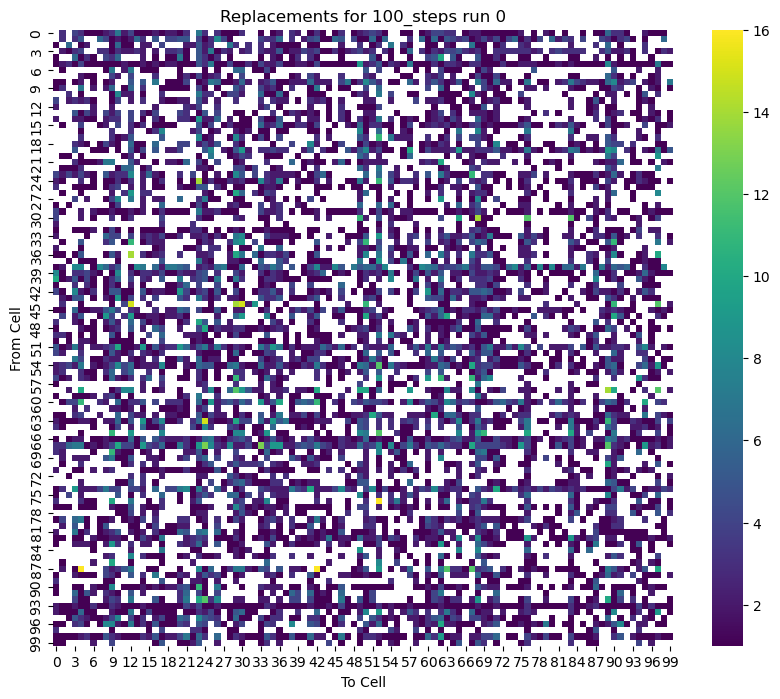

016_steps


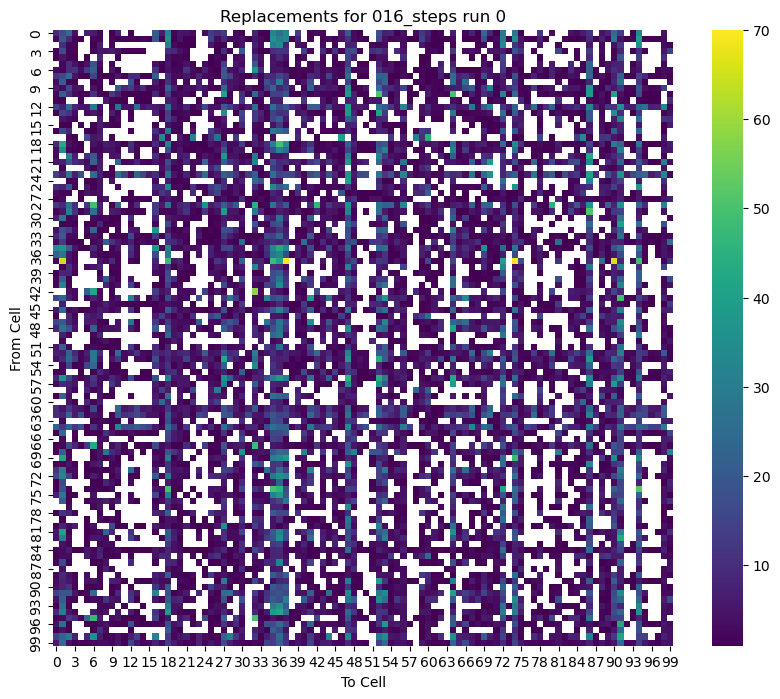

000_steps


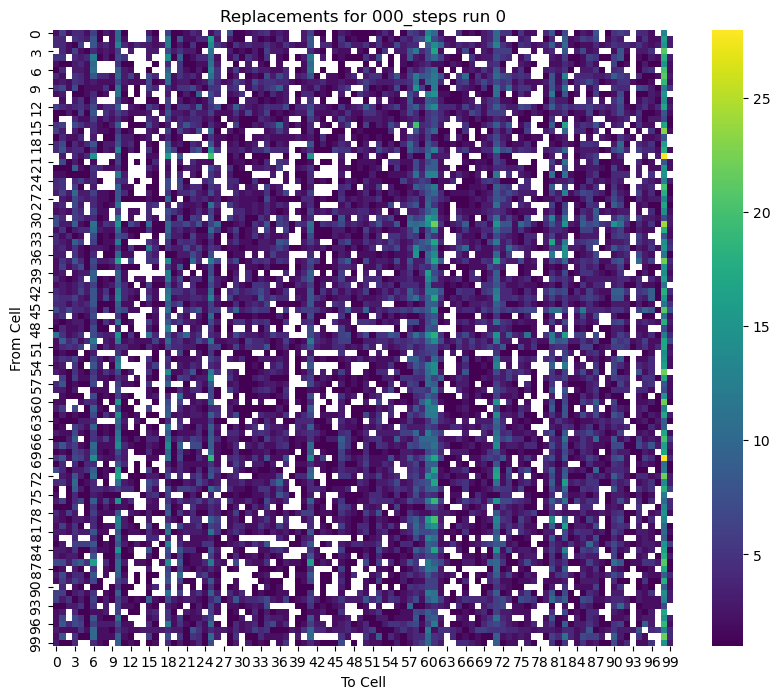

1000_steps


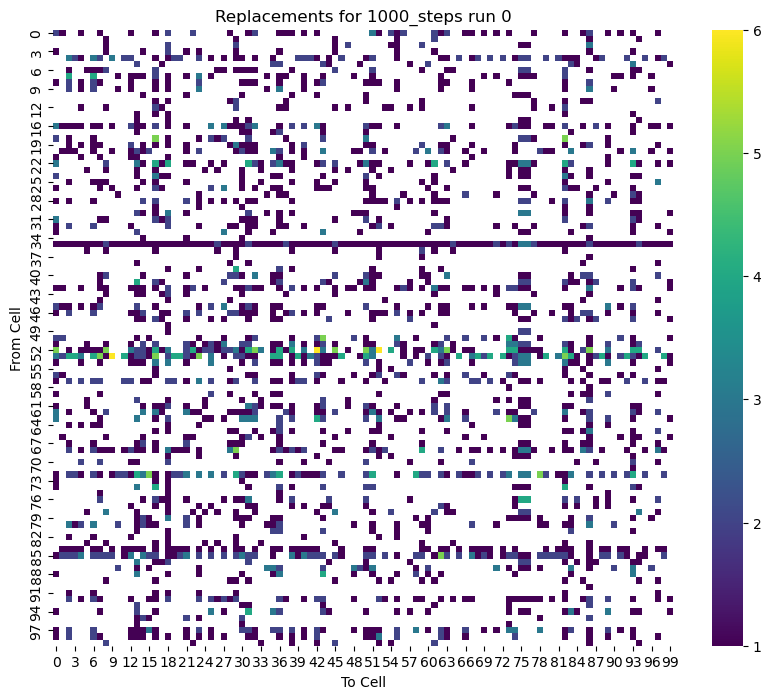

In [12]:
# plot a heatmap for the first default run
for condition in df['condition'].unique():
    print(condition)
    plot_run_heatmap(df, condition, df[df['condition']==condition]['run'].unique()[0], title=f"Replacements for {condition} run 0")


../../results/sgd-steps-euc/conditions/
100_steps run_16474890606919291376
../../results/sgd-steps-euc/conditions/
100_steps run_7646474365221868016
../../results/sgd-steps-euc/conditions/
100_steps run_13761078197689651696
../../results/sgd-steps-euc/conditions/
100_steps run_13759876766487941616
../../results/sgd-steps-euc/conditions/
100_steps run_15088292756520243696
../../results/sgd-steps-euc/conditions/
100_steps run_15087148190685532656
../../results/sgd-steps-euc/conditions/
100_steps run_6904469793611387376
../../results/sgd-steps-euc/conditions/
100_steps run_20893994272297456
../../results/sgd-steps-euc/conditions/
100_steps run_2592189716390482416
../../results/sgd-steps-euc/conditions/
100_steps run_11664017491496407536
../../results/sgd-steps-euc/conditions/
100_steps run_7299463676518339056
../../results/sgd-steps-euc/conditions/
100_steps run_5497592104056525296
../../results/sgd-steps-euc/conditions/
100_steps run_21133352799703536
../../results/sgd-steps-euc/conditio

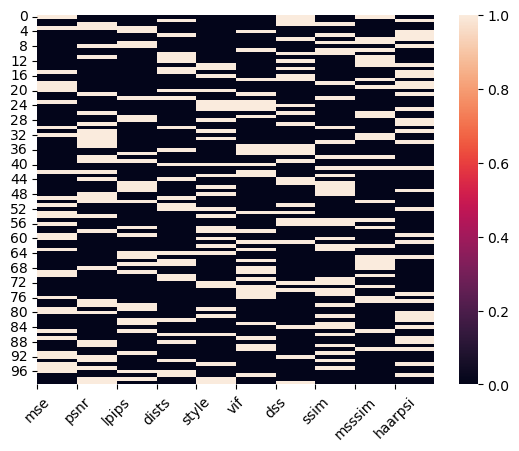

In [13]:
# load masks

# iterate conditions and runs
masks = {}
fns_names = {}

for cond, run, data in replacements:
    print(os.path.join(results_path, f"conditions/"))
    if not os.path.exists( os.path.join(results_path, f"conditions/{cond}/{run}/fn_mask.pt")):
        continue
    print(cond, run)
    mask_path = os.path.join(results_path, f"conditions/{cond}/{run}/fn_mask.pt")
    mask = torch.load(mask_path, map_location='cpu')
    masks[(cond, run)] = mask.cpu()
    if not os.path.exists(os.path.join(results_path, f"conditions/{cond}/{run}/function_names.csv")):
        continue
    with open(os.path.join(results_path, f"conditions/{cond}/{run}/function_names.csv"), 'r') as f:
        fns = f.read().split(",")
        fns_names[(cond, run)] = fns
    

sns.heatmap(masks[list(masks.keys())[0]].T)
plt.xticks(ticks=np.arange(0, len(fns_names[list(masks.keys())[-1]]), step=1), labels=fns_names[list(masks.keys())[-1]], rotation=45)
plt.show()

    condition    replace
0   000_steps  1952838.0
1   016_steps  1730880.0
2  1000_steps    97100.0
3   100_steps   426852.0


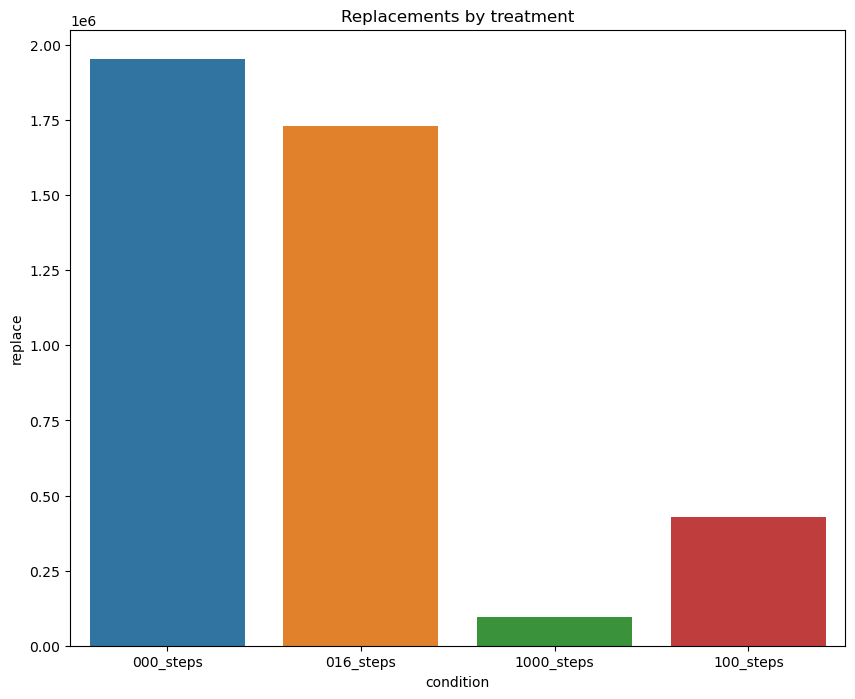

In [14]:
# plot sum of replaces
def plot_replace_sum(df, title='Replacements by treatment'):
    plot_data = df.groupby('condition')['replace'].sum().reset_index()
    print(plot_data)
    plt.figure(figsize=(10, 8))
    sns.barplot(data=plot_data, x='condition', y='replace')
    plt.title(title)
    plt.show()


plot_replace_sum(df, title='Replacements by treatment')


In [15]:
def euc_distance(a, b):
    return np.linalg.norm(a.astype(float) - b.astype(float))

def euc_distance_of_jump(jump):
    return euc_distance(jump[0], jump[1])

def euc_distance_of_replacements(df):
    # df_filtered = df[(df['run'] == run) & (df['condition'] == condition)]
    # if not (condition, run) in masks:
        # return 0.0, {}
    for condition, run in masks.keys():
        mask = masks[(condition, run)].cpu().numpy()

        # Extract relevant columns
        # from_cells = df_filtered['from cell'].values
        # to_cells = df_filtered['to cell'].values
        # batches = df['batch'].values
        replacements = df['replace'].values

        print(replacements.shape)
        print(mask.shape)

        n_cells = mask.shape[-1]
        # n_gens = df['batch'].max() + 1
        # Reshape the replacements array to match the mask's shape
        # replacements_reshaped = replacements.reshape((n_cells, n_cells, n_gens))

        mean_dist = np.mean([euc_distance(mask[:, i], mask[:, j]) for i in range(n_cells) for j in range(n_cells)])

        dist_lookup = {}
        for i in range(n_cells):
            for j in range(n_cells):
                dist_lookup[(i, j)] = euc_distance(mask[:, i], mask[:, j])
                
        df['euc_dist'] = df.apply(lambda x: x['replace']*dist_lookup[(x['from_cell'], x['to_cell'])], axis=1)
    return mean_dist, dist_lookup

if not FORCE_RELOAD and os.path.exists(os.path.join(results_path, "replacements_euc_dist_df.pkl")):
    df = pd.read_pickle(os.path.join(results_path, "replacements_euc_dist_df.pkl"))
else:
    mean_dist, dist_lookup = euc_distance_of_replacements(df)
    df.to_pickle(os.path.join(results_path, "replacements_euc_dist_df.pkl"))



    
    

(4207670,)
(10, 100)


(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(10, 100)
(4207670,)
(1

In [16]:
# load the distances
assert os.path.exists(os.path.join(results_path, "replacements_euc_dist_df.pkl"))
euc_df = pd.read_pickle(os.path.join(results_path, "replacements_euc_dist_df.pkl"))
euc_df.tail(100)

,condition,run,from_cell,to_cell,batch,replace,evals_by_batch,euc_dist
10447468,000_steps,run_15585249412164096496,99,59,477,1.0,478000.0,2.449490
10447890,000_steps,run_15585249412164096496,99,59,899,1.0,900000.0,2.449490
10448042,000_steps,run_15585249412164096496,99,60,2,1.0,3000.0,2.449490
10449091,000_steps,run_15585249412164096496,99,61,2,1.0,3000.0,2.449490
10450140,000_steps,run_15585249412164096496,99,62,2,1.0,3000.0,2.000000
10451189,000_steps,run_15585249412164096496,99,63,2,1.0,3000.0,2.000000
10452253,000_steps,run_15585249412164096496,99,64,17,1.0,18000.0,2.449490
10452786,000_steps,run_15585249412164096496,99,64,550,1.0,551000.0,2.449490
10453297,000_steps,run_15585249412164096496,99,65,12,1.0,13000.0,2.000000
10453715,000_steps,run_15585249412164096496,99,65,430,1.0,431000.0,2.000000


In [17]:

# plot dists
def plot_euc_distance_map(euc_df, condition, run):
    dists = euc_df[(euc_df['condition'] == condition) & (euc_df['run'] == run)]
    # average over from-to cell pairs
    dists = dists.groupby(['from_cell', 'to_cell'])['euc_dist'].mean().reset_index()
    # Convert dictionary to DataFrame
    # Pivot the DataFrame to create a matrix
    heatmap_data = dists.pivot(index='from_cell', columns='to_cell', values='euc_dist')

    # Plot the heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_data, cmap='viridis')
    plt.title(f'Euclidean distance heatmap')
    plt.xlabel('To Cell')
    plt.ylabel('From Cell')
    plt.show()
    
def plot_euc_distance_time(dists):
    # plot a lineplot of the average distance over time
    plt.figure(figsize=(10, 8))
    
    this_dists =  dists.copy()
    # drop nan
    this_dists = this_dists.dropna()
    
    
    this_dists = this_dists.reset_index()
    
    sns.lineplot(data=this_dists, x='evals', y='euc_dist', hue='condition')
    plt.title(f'Average Euclidean distance over time')
    plt.xlabel('Evals')
    plt.ylabel('Distance')
    plt.show()
    



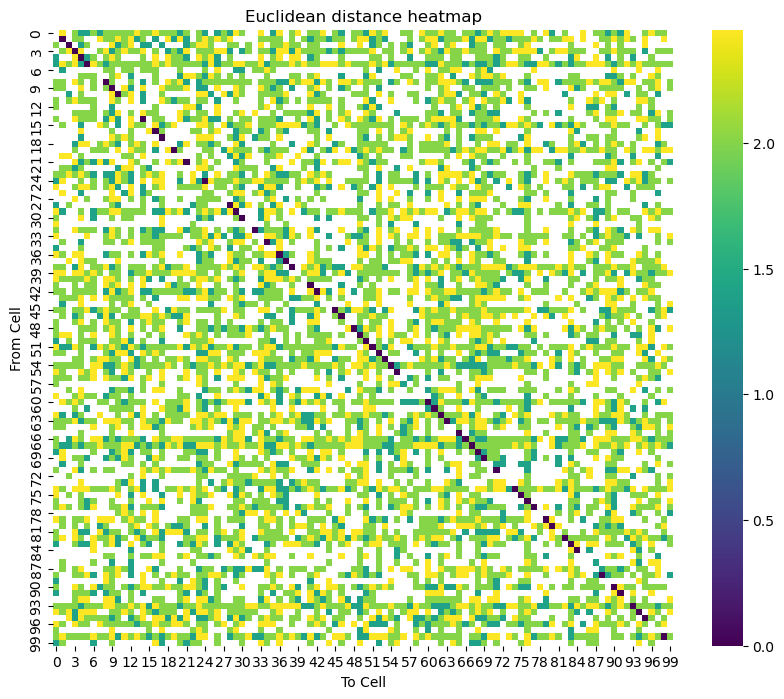

In [18]:
plot_euc_distance_map(euc_df, euc_df['condition'].unique()[0], euc_df['run'].unique()[0])

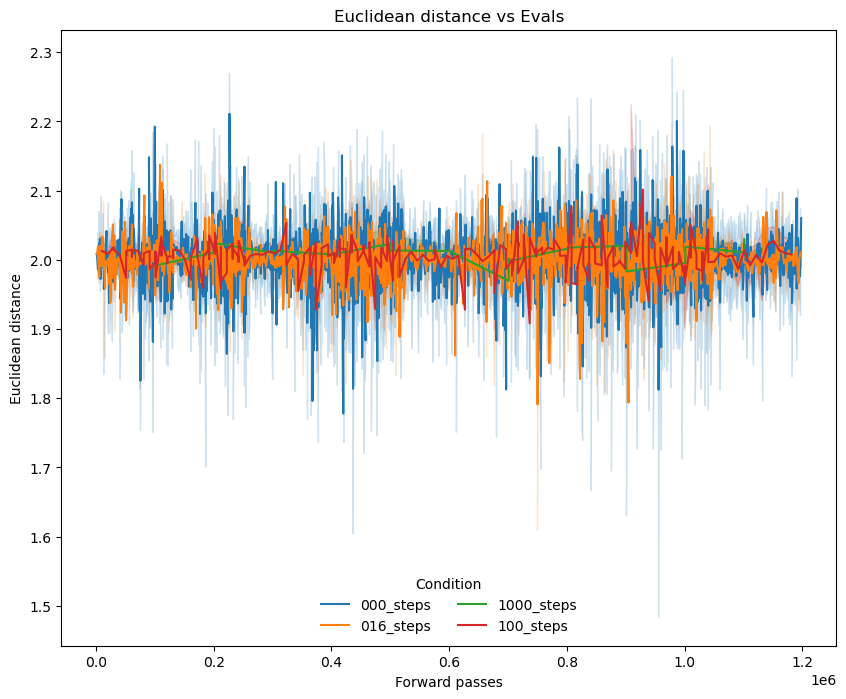

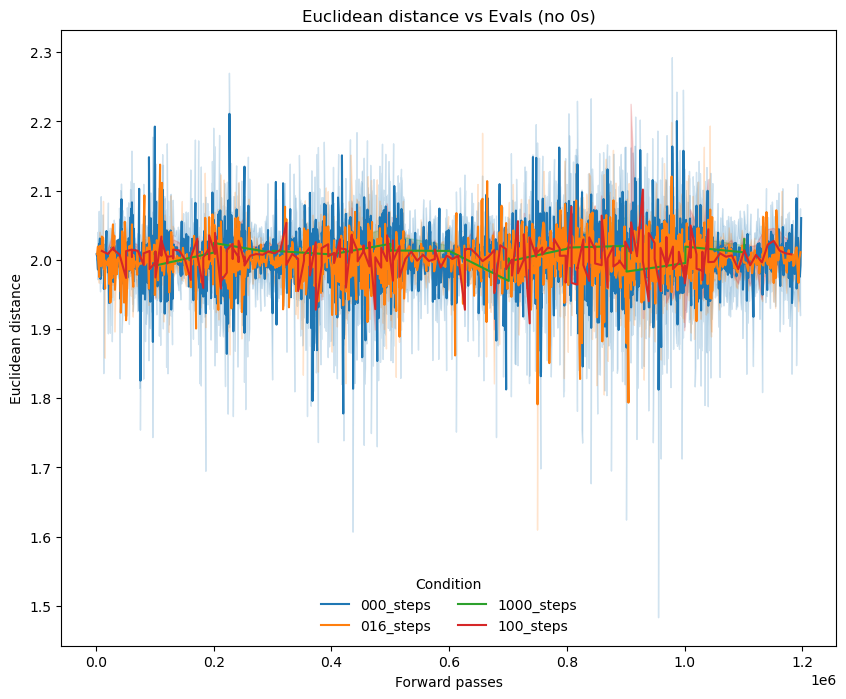

In [19]:
# plot_euc_distance_time(euc_df)
# results, y, save_path=None, show=False, mean_by_target=False,smooth=None, title=None, y_label=None, x_label=None, experiment_name= None, leg_title=None, x_axis_as_prop=False):
plot_vs_evals(euc_df,y='euc_dist',save_path=os.path.join(results_path, "plots"), show=True, mean_by_target=True, smooth=0.1, title='Euclidean distance vs Evals', y_label='Euclidean distance', x_label='Evals', experiment_name='Evals', leg_title='Condition')
plot_vs_evals(euc_df[euc_df['replace']>0],y='euc_dist',save_path=os.path.join(results_path, "plots"), show=True, mean_by_target=True, smooth=0.1, title='Euclidean distance vs Evals (no 0s)', y_label='Euclidean distance', x_label='Evals', experiment_name='Evals_No_0', leg_title='Condition')


In [20]:
euc_df['condition'].unique()

array(['100_steps', '016_steps', '000_steps', '1000_steps'], dtype=object)

In [21]:
# sort by condition, run
euc_df = euc_df.sort_values(by=['condition', 'run'])

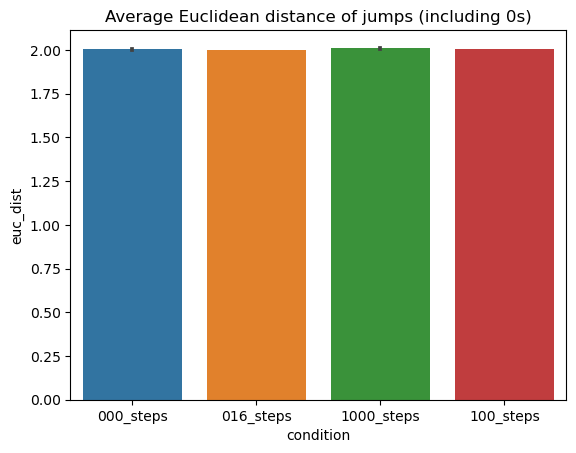

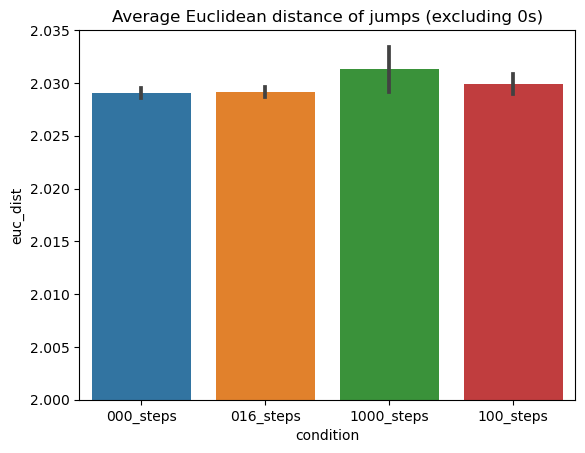

In [22]:
# compare average jump euc distance
# get the average jump distance for each run

# avg_jump_dists = all_jump_dists.groupby(['condition', 'run']).mean().reset_index()

sns.barplot(data=euc_df, x='condition', y='euc_dist')
plt.title("Average Euclidean distance of jumps (including 0s)")
plt.show()


sns.barplot(data=euc_df[euc_df['euc_dist'] > 0], x='condition', y='euc_dist')
plt.ylim(2.0,2.035)
plt.title("Average Euclidean distance of jumps (excluding 0s)")
plt.show()

In [23]:
# check for significant differences between conditions
test_df = euc_df[euc_df['euc_dist'] > 0]

from stats import get_stats_by_condition

means, stds, cis, p_values, confidence = get_stats_by_condition(test_df, 'condition', 'euc_dist')

In [24]:
p_values

{('000_steps', '016_steps'): 0.907021187923183,
 ('000_steps', '1000_steps'): 0.0020136057062252943,
 ('000_steps', '100_steps'): 0.2544982880872303,
 ('016_steps', '000_steps'): 0.907021187923183,
 ('016_steps', '1000_steps'): 0.7020480791407737,
 ('016_steps', '100_steps'): 0.4240875159561087,
 ('1000_steps', '000_steps'): 0.0020136057062252943,
 ('1000_steps', '016_steps'): 0.7020480791407737,
 ('1000_steps', '100_steps'): 0.3041299238363603,
 ('100_steps', '000_steps'): 0.2544982880872303,
 ('100_steps', '016_steps'): 0.4240875159561087,
 ('100_steps', '1000_steps'): 0.3041299238363603}

In [25]:
print("Means", end="\n\t")
print("\n\t".join([f"{m}: {means[m]:.3f} +/- {cis[m][1]-cis[m][0]:.3f}" for i, m in enumerate(means)]))

print("P-Values", end="\n\t")
p_values = {tuple(sorted(list(k))):v for k, v in p_values.items()}
print("\n\t".join([f"{m[0]} vs {m[1]}: {p_values[m]:.3f}" for i, m in enumerate(p_values)]))

Means
	000_steps: 2.029 +/- 0.001
	016_steps: 2.029 +/- 0.001
	1000_steps: 2.031 +/- 0.004
	100_steps: 2.030 +/- 0.002
P-Values
	000_steps vs 016_steps: 0.907
	000_steps vs 1000_steps: 0.002
	000_steps vs 100_steps: 0.254
	016_steps vs 1000_steps: 0.702
	016_steps vs 100_steps: 0.424
	1000_steps vs 100_steps: 0.304


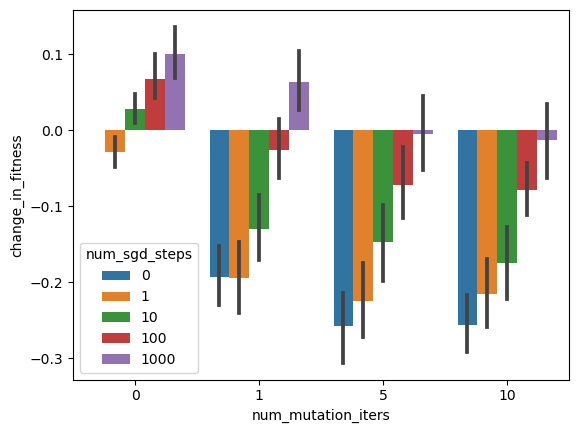

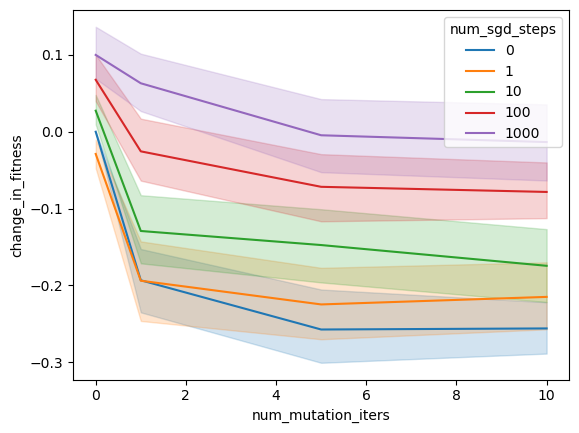

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("./n_mutations_by_sgd.csv")


sns.barplot(data=df, x="num_mutation_iters", y="change_in_fitness", hue="num_sgd_steps")
plt.savefig("./n_mutations_by_sgd.png")
plt.show()

#as line
sns.lineplot(data=df, x="num_mutation_iters", y="change_in_fitness", hue="num_sgd_steps", palette="tab10")
plt.savefig("./n_mutations_by_sgd_line.png")
plt.show()

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
 [Text(0, 0, 'MOVE-SGD-Grow-And-Prune-No-Min-500-steps'),
  Text(1, 0, 'MOVE-SGD-Start-Small-No-Grow-500-steps'),
  Text(2, 0, 'MOVE-SGD-Start-Big-No-Grow-0-steps'),
  Text(3, 0, 'MOVE-SGD-Fast-Grow-0-steps'),
  Text(4, 0, 'MOVE-SGD-Slow-Growth-500-steps'),
  Text(5, 0, 'MOVE-SGD-Grow-And-Prune-500-steps'),
  Text(6, 0, 'MOVE-SGD-Fast-Grow-500-steps'),
  Text(7, 0, 'MOVE-SGD-Grow-And-Prune-0-steps'),
  Text(8, 0, 'MOVE-SGD-Grow-And-Prune-No-Min-0-steps'),
  Text(9, 0, 'MOVE-SGD-Start-Small-No-Grow-0-steps'),
  Text(10, 0, 'MOVE-SGD-Start-Big-No-Grow-500-steps'),
  Text(11, 0, 'MOVE-SGD-Grow-And-Prune-Less-500-steps'),
  Text(12, 0, 'MOVE-SGD-Grow-And-Prune-Less-0-steps')])

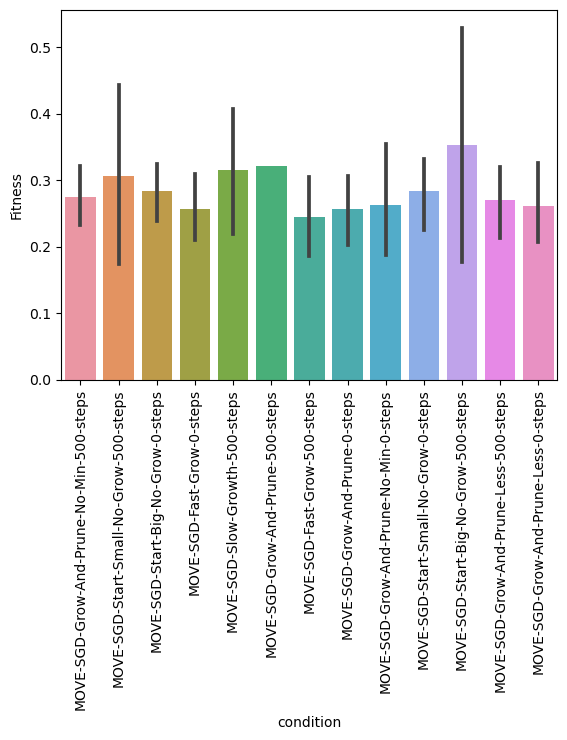

In [27]:
# do the same with analysis/partial_fitness.csv
df = pd.read_csv("partial_fitness.csv")
sns.barplot(data=df, x="condition", y="genome_start_fitness")
plt.ylabel("Fitness")
plt.savefig("partial_fitness.png")
# labels rotated
plt.xticks(rotation=90)